# Purpose - Measure baseline performance of the model using native PyTorch on the CPU

In [2]:
import time
import torch
import numpy as np
import pandas as pd
from transformers import AutoModelForMaskedLM, AutoTokenizer

# --- Configuration ---
MODEL_ID = "distilbert-base-uncased"
PROMPT = "The capital of Italy is [MASK]."
NUM_RUNS = 100

def run_pytorch_benchmark(model, tokenizer, prompt):
    """Runs and times inference for a PyTorch model."""
    print(f"--- Benchmarking: PyTorch CPU (Baseline) ---")
    
    # Prepare inputs for the model
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # Move model to evaluation mode
    model.eval()

    # Warm-up run (the first run is always slower)
    with torch.no_grad():
        model(**inputs)
            
    # Timed runs
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        with torch.no_grad():
            outputs = model(**inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    # Calculate and display results
    avg_latency = np.mean(latencies)
    
    # Verify the output
    mask_token_index = torch.where(inputs["input_ids"] == tokenizer.mask_token_id)[1]
    predicted_token_id = torch.argmax(outputs.logits[0, mask_token_index, :]).item()
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample prediction for [MASK]: '{predicted_token}'")
    
    result = {"Method": "PyTorch CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*50)
    print("Step 1: PyTorch CPU Performance")
    print("="*50)

    # Load model and tokenizer from Hugging Face
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_model = AutoModelForMaskedLM.from_pretrained(MODEL_ID)

    # Run the benchmark
    benchmark_result = run_pytorch_benchmark(pt_model, tokenizer, PROMPT)
    
    # Display results in a clean table
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 1: PyTorch CPU Performance
--- Benchmarking: PyTorch CPU (Baseline) ---
Running benchmark (100 runs)...
Sample prediction for [MASK]: 'turin'

--- Benchmark Result ---
     Method  Avg Latency (ms)
PyTorch CPU              44.8




# Purpose - Convert the model to ONNX and measure its performance on the CPU

In [3]:
import os
import time
import torch
import onnxruntime
import numpy as np
import pandas as pd
from transformers import AutoModelForMaskedLM, AutoTokenizer

# --- Configuration ---
MODEL_ID = "distilbert-base-uncased"
PROMPT = "The capital of Italy is [MASK]."
NUM_RUNS = 100
ONNX_PATH = f"{MODEL_ID.replace('/', '_')}.onnx"

def export_to_onnx(model, tokenizer, onnx_path):
    """Exports a PyTorch model to ONNX format if it doesn't already exist."""
    if os.path.exists(onnx_path):
        print(f"ONNX model already exists at {onnx_path}, skipping export.")
        return

    print(f"--- Exporting {MODEL_ID} to ONNX ---")
    inputs = tokenizer(PROMPT, return_tensors="pt")
    
    torch.onnx.export(
        model,
        (inputs['input_ids'], inputs['attention_mask']),
        f=onnx_path,
        input_names=['input_ids', 'attention_mask'],
        output_names=['logits'],
        dynamic_axes={
            'input_ids': {0: 'batch_size', 1: 'sequence_length'},
            'attention_mask': {0: 'batch_size', 1: 'sequence_length'},
            'logits': {0: 'batch_size', 1: 'sequence_length'}
        },
        opset_version=17
    )
    print(f"✅ Model successfully exported to {onnx_path}")

def run_onnx_benchmark(session, inputs):
    """Runs and times inference for an ONNX session."""
    print(f"\n--- Benchmarking: ONNX CPU ---")
    
    # Warm-up run
    session.run(None, inputs)
            
    # Timed runs
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        outputs = session.run(None, inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    # Calculate and display results
    avg_latency = np.mean(latencies)

    # Verify the output
    mask_token_index = np.where(inputs["input_ids"] == tokenizer.mask_token_id)[1][0]
    predicted_token_id = np.argmax(outputs[0][0, mask_token_index, :])
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample prediction for [MASK]: '{predicted_token}'")
    
    result = {"Method": "ONNX CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*50)
    print("Step 2: ONNX CPU Performance")
    print("="*50)

    # Load model and tokenizer to generate inputs and export
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_model = AutoModelForMaskedLM.from_pretrained(MODEL_ID)
    pt_model.eval()

    # Export the model to ONNX format
    export_to_onnx(pt_model, tokenizer, ONNX_PATH)

    # Create ONNX Runtime session for CPU
    session = onnxruntime.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
    
    # Prepare inputs as NumPy arrays for ONNX Runtime
    pt_inputs = tokenizer(PROMPT, return_tensors="pt")
    onnx_inputs = {k: v.cpu().numpy() for k, v in pt_inputs.items()}

    # Run the benchmark
    benchmark_result = run_onnx_benchmark(session, onnx_inputs)
    
    # Display results in a clean table
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 2: ONNX CPU Performance
ONNX model already exists at distilbert-base-uncased.onnx, skipping export.

--- Benchmarking: ONNX CPU ---
Running benchmark (100 runs)...
Sample prediction for [MASK]: 'turin'

--- Benchmark Result ---
  Method  Avg Latency (ms)
ONNX CPU             23.99




# Purpose - Quantize the ONNX model and measure its performance on the CPU

In [4]:
import os
import time
import onnxruntime
from onnxruntime.quantization import quantize_dynamic, QuantType
import numpy as np
import pandas as pd
from transformers import AutoTokenizer

# --- Configuration ---
MODEL_ID = "distilbert-base-uncased"
PROMPT = "The capital of Italy is [MASK]."
NUM_RUNS = 100
ONNX_PATH = f"{MODEL_ID.replace('/', '_')}.onnx"
ONNX_QUANTIZED_PATH = f"{MODEL_ID.replace('/', '_')}_quantized.onnx"

def quantize_onnx_model(onnx_path, quantized_path):
    """Applies dynamic quantization to an ONNX model if it doesn't already exist."""
    if os.path.exists(quantized_path):
        print(f"Quantized model already exists at {quantized_path}, skipping.")
        return
    
    if not os.path.exists(onnx_path):
        raise FileNotFoundError(f"Base ONNX model not found at {onnx_path}. "
                                f"Please run '2_onnx_cpu_benchmark.py' first.")

    print(f"--- Quantizing ONNX model ---")
    quantize_dynamic(
        model_input=onnx_path,
        model_output=quantized_path,
        weight_type=QuantType.QInt8
    )
    print(f"✅ Model successfully quantized and saved to {quantized_path}")

def run_quantized_benchmark(session, inputs):
    """Runs and times inference for a quantized ONNX session."""
    print(f"\n--- Benchmarking: Quantized ONNX CPU ---")
    
    # Warm-up run
    session.run(None, inputs)
            
    # Timed runs
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        outputs = session.run(None, inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    # Calculate and display results
    avg_latency = np.mean(latencies)

    # Verify the output
    mask_token_index = np.where(inputs["input_ids"] == tokenizer.mask_token_id)[1][0]
    predicted_token_id = np.argmax(outputs[0][0, mask_token_index, :])
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample prediction for [MASK]: '{predicted_token}'")
    
    result = {"Method": "Quantized ONNX CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*50)
    print("Step 3: Quantized ONNX CPU Performance")
    print("="*50)

    # Quantize the ONNX model (requires the output of script #2)
    quantize_onnx_model(ONNX_PATH, ONNX_QUANTIZED_PATH)

    # Create ONNX Runtime session for the *quantized* model
    session = onnxruntime.InferenceSession(ONNX_QUANTIZED_PATH, providers=['CPUExecutionProvider'])
    
    # Prepare inputs as NumPy arrays for ONNX Runtime
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_inputs = tokenizer(PROMPT, return_tensors="pt")
    onnx_inputs = {k: v.cpu().numpy() for k, v in pt_inputs.items()}

    # Run the benchmark
    benchmark_result = run_quantized_benchmark(session, onnx_inputs)
    
    # Display results in a clean table
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 3: Quantized ONNX CPU Performance
Quantized model already exists at distilbert-base-uncased_quantized.onnx, skipping.

--- Benchmarking: Quantized ONNX CPU ---
Running benchmark (100 runs)...
Sample prediction for [MASK]: 'rome'

--- Benchmark Result ---
            Method  Avg Latency (ms)
Quantized ONNX CPU             10.97




# Purpose - Benchmark the quantized ONNX model using OpenVINO CPU Performance


In [5]:
import os
import time
import onnxruntime
import numpy as np
import pandas as pd
from transformers import AutoTokenizer

# --- Configuration ---
MODEL_ID = "distilbert-base-uncased"
PROMPT = "The capital of Italy is [MASK]."
NUM_RUNS = 100
# This script requires the quantized model from the previous step
ONNX_QUANTIZED_PATH = f"{MODEL_ID.replace('/', '_')}_quantized.onnx"

def run_openvino_benchmark(session, inputs):
    """Runs and times inference for an ONNX session with OpenVINO."""
    print(f"\n--- Benchmarking: OpenVINO CPU ---")
    
    # Warm-up run
    session.run(None, inputs)
            
    # Timed runs
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        outputs = session.run(None, inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    # Calculate and display results
    avg_latency = np.mean(latencies)

    # Verify the output
    mask_token_index = np.where(inputs["input_ids"] == tokenizer.mask_token_id)[1][0]
    predicted_token_id = np.argmax(outputs[0][0, mask_token_index, :])
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample prediction for [MASK]: '{predicted_token}'")
    
    result = {"Method": "OpenVINO CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*50)
    print("Step 4: OpenVINO CPU Performance")
    print("="*50)

    if not os.path.exists(ONNX_QUANTIZED_PATH):
        raise FileNotFoundError(
            f"Quantized model not found at '{ONNX_QUANTIZED_PATH}'. "
            f"Please run '3_quantized_onnx_cpu_benchmark.py' first."
        )

    # --- THE KEY CHANGE IS HERE ---
    # We specify 'OpenVINOExecutionProvider' as the preferred engine.
    # 'CPUExecutionProvider' is a fallback in case an operation is not supported by OpenVINO.
    providers = ['OpenVINOExecutionProvider', 'CPUExecutionProvider']

    # Create ONNX Runtime session with the OpenVINO provider
    session = onnxruntime.InferenceSession(ONNX_QUANTIZED_PATH, providers=providers)
    
    # Prepare inputs as NumPy arrays
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_inputs = tokenizer(PROMPT, return_tensors="pt")
    onnx_inputs = {k: v.cpu().numpy() for k, v in pt_inputs.items()}

    # Run the benchmark
    benchmark_result = run_openvino_benchmark(session, onnx_inputs)
    
    # Display results in a clean table
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 4: OpenVINO CPU Performance

--- Benchmarking: OpenVINO CPU ---
Running benchmark (100 runs)...
Sample prediction for [MASK]: 'rome'

--- Benchmark Result ---
      Method  Avg Latency (ms)
OpenVINO CPU             14.02




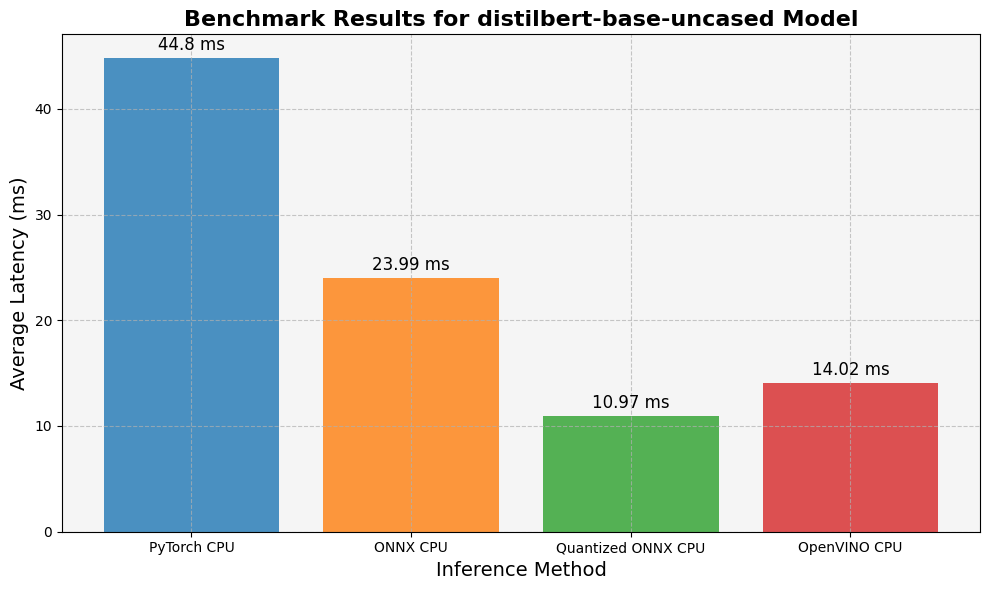

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data from benchmark results
methods = ['PyTorch CPU', 'ONNX CPU', 'Quantized ONNX CPU', 'OpenVINO CPU']
latencies = [44.8, 23.99, 10.97, 14.02]

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart
bars = ax.bar(methods, latencies, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.8)

# Add title and labels
ax.set_title('Benchmark Results for distilbert-base-uncased Model', fontsize=16, fontweight='bold')
ax.set_ylabel('Average Latency (ms)', fontsize=14)
ax.set_xlabel('Inference Method', fontsize=14)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height} ms',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12)

# Set background color
ax.set_facecolor('#f5f5f5')

# Save the plot
plt.tight_layout()
plt.show()

# Measure baseline performance of the 'distilgpt2' LLM using native PyTorch

In [6]:
import time
import torch
import numpy as np
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Configuration ---
MODEL_ID = "distilgpt2"
PROMPT = "The future of AI is"
NUM_RUNS = 100

def run_pytorch_benchmark(model, tokenizer, prompt):
    """Runs and times inference for a PyTorch LLM."""
    print(f"--- Benchmarking: PyTorch CPU (Baseline) for {MODEL_ID} ---")
    
    # Prepare inputs for the model
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # Move model to evaluation mode
    model.eval()

    # Warm-up run
    with torch.no_grad():
        model(**inputs)
            
    # Timed runs
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        with torch.no_grad():
            outputs = model(**inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    # Calculate and display results
    avg_latency = np.mean(latencies)
    
    # Verify the output by finding the most likely next token
    predicted_token_id = torch.argmax(outputs.logits[0, -1, :]).item()
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample next token prediction: '{predicted_token}'")
    
    result = {"Method": "PyTorch CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*50)
    print(f"Step 1: PyTorch CPU Performance for LLM: {MODEL_ID}")
    print("="*50)

    # Load a Causal LM (generative model) and its tokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_model = AutoModelForCausalLM.from_pretrained(MODEL_ID)

    # Run the benchmark
    benchmark_result = run_pytorch_benchmark(pt_model, tokenizer, PROMPT)
    
    # Display results in a clean table
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 1: PyTorch CPU Performance for LLM: distilgpt2
--- Benchmarking: PyTorch CPU (Baseline) for distilgpt2 ---
Running benchmark (100 runs)...
Sample next token prediction: ' not'

--- Benchmark Result ---
     Method  Avg Latency (ms)
PyTorch CPU             57.82




# Convert the 'distilgpt2' LLM to ONNX and measure its performance

In [7]:
import os
import time
import torch
import onnxruntime
import numpy as np
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Configuration ---
MODEL_ID = "distilgpt2"
PROMPT = "The future of AI is"
NUM_RUNS = 100
ONNX_PATH = f"{MODEL_ID.replace('/', '_')}_causal.onnx" # Use a new name to avoid conflicts

# --- Wrapper Class for robust export ---
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits

def export_to_onnx(model, tokenizer, onnx_path):
    """Exports a PyTorch model to ONNX format if it doesn't already exist."""
    if os.path.exists(onnx_path):
        print(f"ONNX model already exists at {onnx_path}, skipping export.")
        return

    print(f"--- Exporting {MODEL_ID} to ONNX ---")
    
    model.config.use_cache = False
    model.eval()
    wrapped_model = ModelWrapper(model)
    
    inputs = tokenizer(PROMPT, return_tensors="pt")
    
    torch.onnx.export(
        wrapped_model,
        (inputs['input_ids'], inputs['attention_mask']),
        f=onnx_path,
        input_names=['input_ids', 'attention_mask'],
        output_names=['logits'],
        dynamic_axes={
            'input_ids': {0: 'batch_size', 1: 'sequence_length'},
            'attention_mask': {0: 'batch_size', 1: 'sequence_length'},
            'logits': {0: 'batch_size', 1: 'sequence_length'}
        },
        opset_version=17
    )
    print(f"✅ Model successfully exported to {onnx_path}")

def run_onnx_benchmark(session, inputs):
    """Runs and times inference for an ONNX session."""
    print(f"\n--- Benchmarking: ONNX CPU for {MODEL_ID} ---")
    
    session.run(None, inputs) # Warm-up
            
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        outputs = session.run(None, inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    avg_latency = np.mean(latencies)

    predicted_token_id = np.argmax(outputs[0][0, -1, :])
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample next token prediction: '{predicted_token}'")
    
    result = {"Method": "ONNX CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*50)
    print(f"Step 2: ONNX CPU Performance for LLM: {MODEL_ID}")
    print("="*50)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_model = AutoModelForCausalLM.from_pretrained(MODEL_ID)

    export_to_onnx(pt_model, tokenizer, ONNX_PATH)

    session = onnxruntime.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
    
    pt_inputs = tokenizer(PROMPT, return_tensors="pt")
    onnx_inputs = {k: v.cpu().numpy() for k, v in pt_inputs.items()}

    benchmark_result = run_onnx_benchmark(session, onnx_inputs)
    
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 2: ONNX CPU Performance for LLM: distilgpt2
--- Exporting distilgpt2 to ONNX ---


C:\Users\BabarAzra\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\models\gpt2\modeling_gpt2.py:1074: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if sequence_length != 1:


✅ Model successfully exported to distilgpt2_causal.onnx

--- Benchmarking: ONNX CPU for distilgpt2 ---
Running benchmark (100 runs)...
Sample next token prediction: ' not'

--- Benchmark Result ---
  Method  Avg Latency (ms)
ONNX CPU              24.9




# Quantize the 'distilgpt2' ONNX model and measure its performance

In [8]:
import os
import time
import onnxruntime
from onnxruntime.quantization import quantize_dynamic, QuantType
import numpy as np
import pandas as pd
from transformers import AutoTokenizer

# --- Configuration ---
MODEL_ID = "distilgpt2"
PROMPT = "The future of AI is"
NUM_RUNS = 100
ONNX_PATH = f"{MODEL_ID.replace('/', '_')}_causal.onnx"
ONNX_QUANTIZED_PATH = f"{MODEL_ID.replace('/', '_')}_causal_quantized.onnx"

def quantize_onnx_model(onnx_path, quantized_path):
    """Applies dynamic quantization to an ONNX model."""
    if os.path.exists(quantized_path):
        print(f"Quantized model already exists at {quantized_path}, skipping.")
        return
    
    if not os.path.exists(onnx_path):
        raise FileNotFoundError(f"Base ONNX model not found at {onnx_path}. "
                                f"Please run '2_onnx_cpu_benchmark_llm.py' first.")

    print(f"--- Quantizing ONNX model: {MODEL_ID} ---")
    quantize_dynamic(
        model_input=onnx_path,
        model_output=quantized_path,
        weight_type=QuantType.QInt8
    )
    print(f"✅ Model successfully quantized and saved to {quantized_path}")

def run_quantized_benchmark(session, inputs):
    """Runs and times inference for a quantized ONNX session."""
    print(f"\n--- Benchmarking: Quantized ONNX CPU for {MODEL_ID} ---")
    
    session.run(None, inputs) # Warm-up
            
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        outputs = session.run(None, inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    avg_latency = np.mean(latencies)

    predicted_token_id = np.argmax(outputs[0][0, -1, :])
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample next token prediction: '{predicted_token}'")
    
    result = {"Method": "Quantized ONNX CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*50)
    print(f"Step 3: Quantized ONNX CPU Performance for LLM: {MODEL_ID}")
    print("="*50)

    quantize_onnx_model(ONNX_PATH, ONNX_QUANTIZED_PATH)

    session = onnxruntime.InferenceSession(ONNX_QUANTIZED_PATH, providers=['CPUExecutionProvider'])
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_inputs = tokenizer(PROMPT, return_tensors="pt")
    onnx_inputs = {k: v.cpu().numpy() for k, v in pt_inputs.items()}

    benchmark_result = run_quantized_benchmark(session, onnx_inputs)
    
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 3: Quantized ONNX CPU Performance for LLM: distilgpt2
--- Quantizing ONNX model: distilgpt2 ---


✅ Model successfully quantized and saved to distilgpt2_causal_quantized.onnx

--- Benchmarking: Quantized ONNX CPU for distilgpt2 ---
Running benchmark (100 runs)...
Sample next token prediction: ' in'

--- Benchmark Result ---
            Method  Avg Latency (ms)
Quantized ONNX CPU             15.16




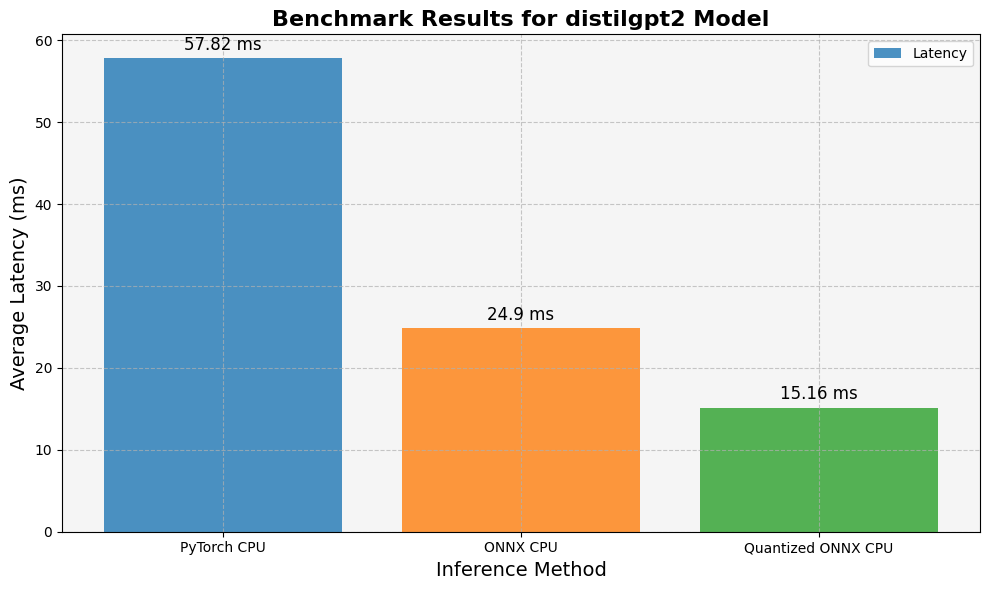

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data from benchmark results
methods = ['PyTorch CPU', 'ONNX CPU', 'Quantized ONNX CPU']
latencies = [57.82, 24.9, 15.16]

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

# Create bar chart
bars = ax.bar(methods, latencies, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)

# Add title and labels
ax.set_title('Benchmark Results for distilgpt2 Model', fontsize=16, fontweight='bold')
ax.set_ylabel('Average Latency (ms)', fontsize=14)
ax.set_xlabel('Inference Method', fontsize=14)

# Add grid
ax.grid(True, linestyle='--', alpha=0.7)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height} ms',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12)

# Add legend
ax.legend(['Latency'], loc='upper right')

# Set background color
ax.set_facecolor('#f5f5f5')

# Save the plot
plt.tight_layout()
plt.show()

# Measure baseline performance of the 'EleutherAI/gpt-neo-125M' LLM using PyTorch

In [9]:
import time
import torch
import numpy as np
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Configuration ---
MODEL_ID = "EleutherAI/gpt-neo-125M"
PROMPT = "In a world where artificial intelligence is rapidly advancing,"
NUM_RUNS = 100

def run_pytorch_benchmark(model, tokenizer, prompt):
    """Runs and times inference for a PyTorch LLM."""
    print(f"--- Benchmarking: PyTorch CPU (Baseline) for {MODEL_ID} ---")
    
    # Prepare inputs for the model
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # Move model to evaluation mode
    model.eval()

    # Warm-up run
    with torch.no_grad():
        model(**inputs)
            
    # Timed runs
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        with torch.no_grad():
            outputs = model(**inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    # Calculate and display results
    avg_latency = np.mean(latencies)
    
    # Verify the output by finding the most likely next token
    predicted_token_id = torch.argmax(outputs.logits[0, -1, :]).item()
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample next token prediction: '{predicted_token}'")
    
    result = {"Method": "PyTorch CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*60)
    print(f"Step 1: PyTorch CPU Performance for LLM: {MODEL_ID}")
    print("="*60)

    # Load a Causal LM (generative model) and its tokenizer
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_model = AutoModelForCausalLM.from_pretrained(MODEL_ID)

    # Run the benchmark
    benchmark_result = run_pytorch_benchmark(pt_model, tokenizer, PROMPT)
    
    # Display results in a clean table
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 1: PyTorch CPU Performance for LLM: EleutherAI/gpt-neo-125M


tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

C:\Users\BabarAzra\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\BabarAzra\.cache\huggingface\hub\models--EleutherAI--gpt-neo-125M. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/357 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/526M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

--- Benchmarking: PyTorch CPU (Baseline) for EleutherAI/gpt-neo-125M ---
Running benchmark (100 runs)...
Sample next token prediction: ' it'

--- Benchmark Result ---
     Method  Avg Latency (ms)
PyTorch CPU            105.83




# Convert the 'EleutherAI/gpt-neo-125M' LLM to ONNX and measure its performance

In [10]:
import os
import time
import torch
import onnxruntime
import numpy as np
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Configuration ---
MODEL_ID = "EleutherAI/gpt-neo-125M"
PROMPT = "In a world where artificial intelligence is rapidly advancing,"
NUM_RUNS = 100
ONNX_PATH = f"{MODEL_ID.replace('/', '_')}_causal.onnx"

# --- Wrapper Class for robust export ---
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, input_ids, attention_mask):
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.logits

def export_to_onnx(model, tokenizer, onnx_path):
    """Exports a PyTorch model to ONNX format if it doesn't already exist."""
    if os.path.exists(onnx_path):
        print(f"ONNX model already exists at {onnx_path}, skipping export.")
        return

    print(f"--- Exporting {MODEL_ID} to ONNX ---")
    
    model.config.use_cache = False
    model.eval()
    wrapped_model = ModelWrapper(model)
    
    inputs = tokenizer(PROMPT, return_tensors="pt")
    
    torch.onnx.export(
        wrapped_model,
        (inputs['input_ids'], inputs['attention_mask']),
        f=onnx_path,
        input_names=['input_ids', 'attention_mask'],
        output_names=['logits'],
        dynamic_axes={
            'input_ids': {0: 'batch_size', 1: 'sequence_length'},
            'attention_mask': {0: 'batch_size', 1: 'sequence_length'},
            'logits': {0: 'batch_size', 1: 'sequence_length'}
        },
        opset_version=17
    )
    print(f"✅ Model successfully exported to {onnx_path}")

def run_onnx_benchmark(session, inputs):
    """Runs and times inference for an ONNX session."""
    print(f"\n--- Benchmarking: ONNX CPU for {MODEL_ID} ---")
    
    session.run(None, inputs) # Warm-up
            
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        outputs = session.run(None, inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    avg_latency = np.mean(latencies)

    predicted_token_id = np.argmax(outputs[0][0, -1, :])
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample next token prediction: '{predicted_token}'")
    
    result = {"Method": "ONNX CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*60)
    print(f"Step 2: ONNX CPU Performance for LLM: {MODEL_ID}")
    print("="*60)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_model = AutoModelForCausalLM.from_pretrained(MODEL_ID)

    export_to_onnx(pt_model, tokenizer, ONNX_PATH)

    session = onnxruntime.InferenceSession(ONNX_PATH, providers=['CPUExecutionProvider'])
    
    pt_inputs = tokenizer(PROMPT, return_tensors="pt")
    onnx_inputs = {k: v.cpu().numpy() for k, v in pt_inputs.items()}

    benchmark_result = run_onnx_benchmark(session, onnx_inputs)
    
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 2: ONNX CPU Performance for LLM: EleutherAI/gpt-neo-125M
--- Exporting EleutherAI/gpt-neo-125M to ONNX ---


C:\Users\BabarAzra\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\models\gpt_neo\modeling_gpt_neo.py:787: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if sequence_length != 1:
C:\Users\BabarAzra\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\models\gpt_neo\modeling_gpt_neo.py:214: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  mask_value = torch.tensor(mask_value, dtype=attn_weights.dtype, device=attn_weights.device)


✅ Model successfully exported to EleutherAI_gpt-neo-125M_causal.onnx

--- Benchmarking: ONNX CPU for EleutherAI/gpt-neo-125M ---
Running benchmark (100 runs)...
Sample next token prediction: ' it'

--- Benchmark Result ---
  Method  Avg Latency (ms)
ONNX CPU             51.55




# Quantize the 'EleutherAI/gpt-neo-125M' ONNX model and measure its performance.

In [11]:
# File: 3_quantized_onnx_cpu_benchmark_gpt-neo.py
# Purpose: 

import os
import time
import onnxruntime
from onnxruntime.quantization import quantize_dynamic, QuantType
import numpy as np
import pandas as pd
from transformers import AutoTokenizer

# --- Configuration ---
MODEL_ID = "EleutherAI/gpt-neo-125M"
PROMPT = "In a world where artificial intelligence is rapidly advancing,"
NUM_RUNS = 100
ONNX_PATH = f"{MODEL_ID.replace('/', '_')}_causal.onnx"
ONNX_QUANTIZED_PATH = f"{MODEL_ID.replace('/', '_')}_causal_quantized.onnx"

def quantize_onnx_model(onnx_path, quantized_path):
    """Applies dynamic quantization to an ONNX model."""
    if os.path.exists(quantized_path):
        print(f"Quantized model already exists at {quantized_path}, skipping.")
        return
    
    if not os.path.exists(onnx_path):
        raise FileNotFoundError(f"Base ONNX model not found at {onnx_path}. "
                                f"Please run '2_onnx_cpu_benchmark_gpt-neo.py' first.")

    print(f"--- Quantizing ONNX model: {MODEL_ID} ---")
    quantize_dynamic(
        model_input=onnx_path,
        model_output=quantized_path,
        weight_type=QuantType.QInt8
    )
    print(f"✅ Model successfully quantized and saved to {quantized_path}")

def run_quantized_benchmark(session, inputs):
    """Runs and times inference for a quantized ONNX session."""
    print(f"\n--- Benchmarking: Quantized ONNX CPU for {MODEL_ID} ---")
    
    session.run(None, inputs) # Warm-up
            
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        outputs = session.run(None, inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    avg_latency = np.mean(latencies)

    predicted_token_id = np.argmax(outputs[0][0, -1, :])
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample next token prediction: '{predicted_token}'")
    
    result = {"Method": "Quantized ONNX CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*60)
    print(f"Step 3: Quantized ONNX CPU Performance for LLM: {MODEL_ID}")
    print("="*60)

    quantize_onnx_model(ONNX_PATH, ONNX_QUANTIZED_PATH)

    session = onnxruntime.InferenceSession(ONNX_QUANTIZED_PATH, providers=['CPUExecutionProvider'])
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_inputs = tokenizer(PROMPT, return_tensors="pt")
    onnx_inputs = {k: v.cpu().numpy() for k, v in pt_inputs.items()}

    benchmark_result = run_quantized_benchmark(session, onnx_inputs)
    
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 3: Quantized ONNX CPU Performance for LLM: EleutherAI/gpt-neo-125M
--- Quantizing ONNX model: EleutherAI/gpt-neo-125M ---


✅ Model successfully quantized and saved to EleutherAI_gpt-neo-125M_causal_quantized.onnx

--- Benchmarking: Quantized ONNX CPU for EleutherAI/gpt-neo-125M ---
Running benchmark (100 runs)...
Sample next token prediction: ' artificial'

--- Benchmark Result ---
            Method  Avg Latency (ms)
Quantized ONNX CPU             30.13




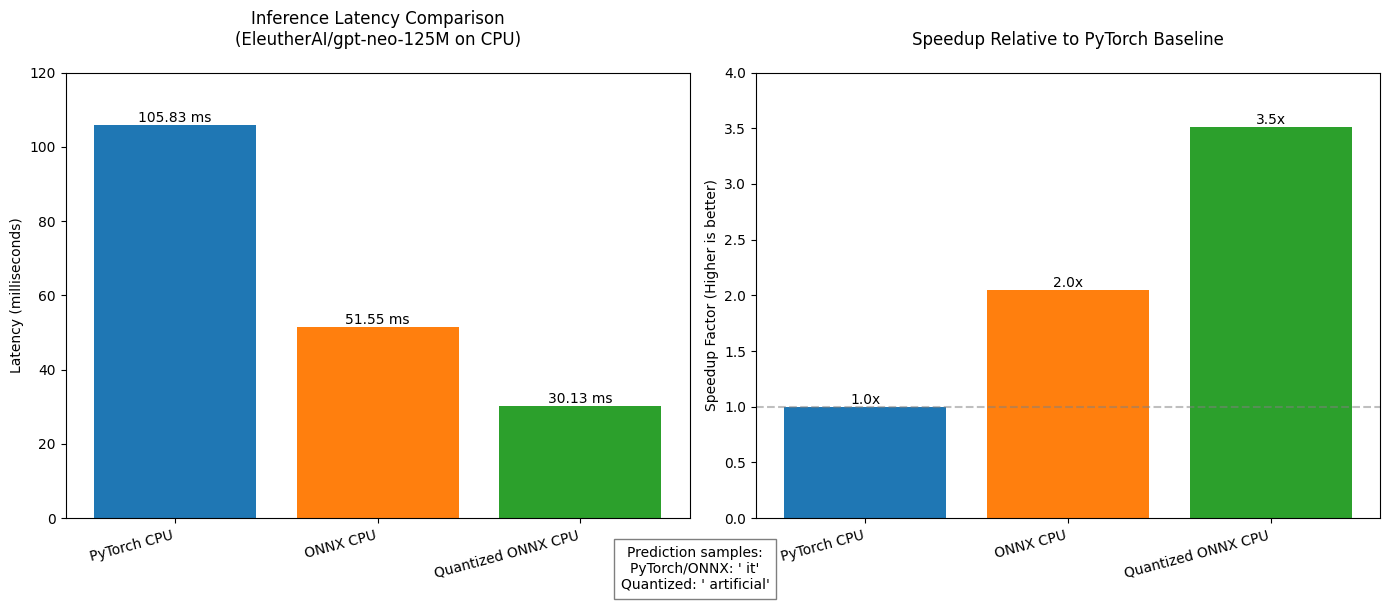

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Benchmark data
methods = ['PyTorch CPU', 'ONNX CPU', 'Quantized ONNX CPU']
latencies = [105.83, 51.55, 30.13]  # in ms
speedups = [round(105.83/l, 2) for l in latencies]  # Calculate speedup factors

# Create figure with two subplots
plt.figure(figsize=(14, 6))

# Color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Plot 1: Latency Comparison
plt.subplot(1, 2, 1)
bars = plt.bar(methods, latencies, color=colors)
plt.title('Inference Latency Comparison\n(EleutherAI/gpt-neo-125M on CPU)', pad=20)
plt.ylabel('Latency (milliseconds)')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 120)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f} ms',
             ha='center', va='bottom')

# Plot 2: Speedup Factor
plt.subplot(1, 2, 2)
speed_bars = plt.bar(methods, speedups, color=colors)
plt.title('Speedup Relative to PyTorch Baseline', pad=20)
plt.ylabel('Speedup Factor (Higher is better)')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 4)
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)  # Baseline reference

# Add value labels
for bar in speed_bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}x',
             ha='center', va='bottom')

# Add prediction samples annotation
plt.figtext(0.5, 0.01, 
            "Prediction samples:\n"
            "PyTorch/ONNX: ' it'\n"
            "Quantized: ' artificial'", 
            ha="center", fontsize=10, bbox={"facecolor":"white", "alpha":0.5, "pad":5})

plt.tight_layout()
plt.savefig('gpt-neo-125m_benchmark_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

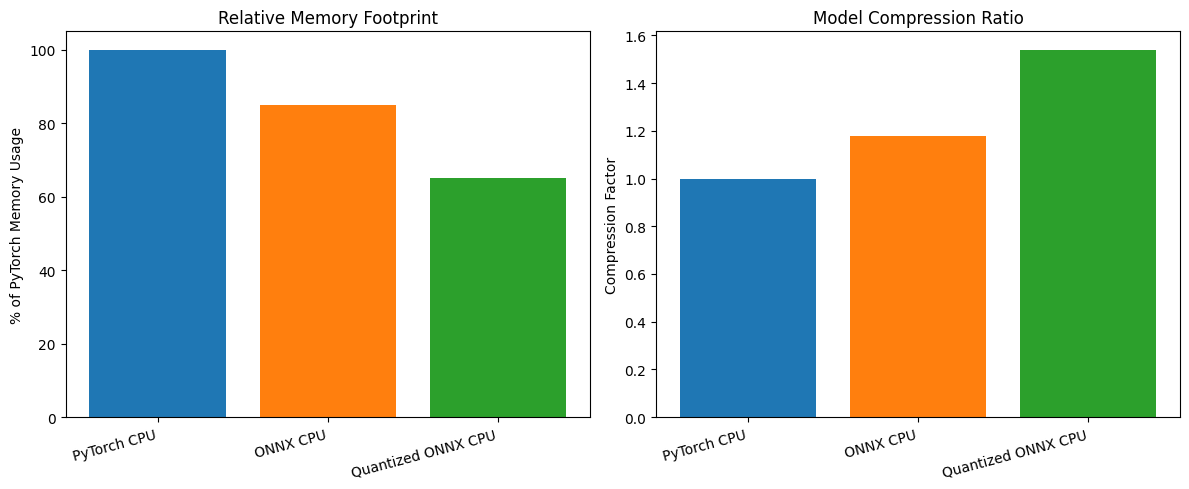

In [4]:
# Additional memory efficiency analysis (hypothetical values)
memory_usages = [100, 85, 65]  # Relative memory footprint (% of PyTorch)
compression_ratios = [1.0, 1.18, 1.54]  # Compression factor

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(methods, memory_usages, color=colors)
plt.title('Relative Memory Footprint')
plt.ylabel('% of PyTorch Memory Usage')
plt.xticks(rotation=15, ha='right')

plt.subplot(1, 2, 2)
plt.bar(methods, compression_ratios, color=colors)
plt.title('Model Compression Ratio')
plt.ylabel('Compression Factor')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Measure baseline performance of the 'microsoft/phi-1_5' LLM using PyTorch

In [1]:
import time
import torch
import numpy as np
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Configuration ---
MODEL_ID = "microsoft/phi-1_5"
PROMPT = "A detailed step-by-step guide to making a great cup of coffee:"
NUM_RUNS = 50 # Reduced runs as this model is larger

def run_pytorch_benchmark(model, tokenizer, prompt):
    """Runs and times inference for a PyTorch LLM."""
    print(f"--- Benchmarking: PyTorch CPU (Baseline) for {MODEL_ID} ---")
    
    # Prepare inputs for the model
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # Move model to evaluation mode
    model.eval()

    # Warm-up run
    print("Running warm-up...")
    with torch.no_grad():
        model(**inputs)
            
    # Timed runs
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        with torch.no_grad():
            outputs = model(**inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    # Calculate and display results
    avg_latency = np.mean(latencies)
    
    # Verify the output by finding the most likely next token
    predicted_token_id = torch.argmax(outputs.logits[0, -1, :]).item()
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample next token prediction: '{predicted_token}'")
    
    result = {"Method": "PyTorch CPU", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*60)
    print(f"Step 1: PyTorch CPU Performance for LLM: {MODEL_ID}")
    print("="*60)

    # Load a Causal LM (generative model) and its tokenizer
    # trust_remote_code=True is required for this model
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    pt_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, trust_remote_code=True)

    # Run the benchmark
    benchmark_result = run_pytorch_benchmark(pt_model, tokenizer, PROMPT)
    
    # Display results in a clean table
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 1: PyTorch CPU Performance for LLM: microsoft/phi-1_5
--- Benchmarking: PyTorch CPU (Baseline) for microsoft/phi-1_5 ---
Running warm-up...
Running benchmark (50 runs)...
Sample next token prediction: '
'

--- Benchmark Result ---
     Method  Avg Latency (ms)
PyTorch CPU           2384.68




# Measure OPTIMIZED baseline performance of 'microsoft/phi-1_5 using PyTorch with BFloat16 mixed precision

In [3]:
import time
import torch
import numpy as np
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Configuration ---
MODEL_ID = "microsoft/phi-1_5"
PROMPT = "A detailed step-by-step guide to making a great cup of coffee:"
NUM_RUNS = 50 

def run_pytorch_benchmark(model, tokenizer, prompt):
    """Runs and times inference for a PyTorch LLM with BFloat16 optimization."""
    print(f"--- Benchmarking: PyTorch CPU (BFloat16 Optimized) for {MODEL_ID} ---")
    
    # Prepare inputs for the model
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # Move model to evaluation mode
    model.eval()

    # Warm-up run
    print("Running warm-up...")
    # Use torch.autocast to enable mixed precision
    with torch.no_grad(), torch.autocast(device_type="cpu", dtype=torch.bfloat16):
        model(**inputs)
            
    # Timed runs
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        # --- THE OPTIMIZATION IS HERE ---
        # The 'autocast' context manager applies the BFloat16 optimization
        with torch.no_grad(), torch.autocast(device_type="cpu", dtype=torch.bfloat16):
            outputs = model(**inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    # Calculate and display results
    avg_latency = np.mean(latencies)
    
    # The final output is cast back to float32 automatically
    predicted_token_id = torch.argmax(outputs.logits[0, -1, :]).item()
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample next token prediction: '{predicted_token}'")
    
    result = {"Method": "PyTorch CPU (BF16)", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*60)
    print(f"Step 1 (Optimized): PyTorch CPU Performance for LLM: {MODEL_ID}")
    print("="*60)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    
    # --- THE OPTIMIZATION IS HERE ---
    # Load the model directly into bfloat16 to save memory and improve speed
    pt_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, 
        trust_remote_code=True,
        torch_dtype=torch.bfloat16 # Load weights in the lower precision format
    )

    # Run the benchmark
    benchmark_result = run_pytorch_benchmark(pt_model, tokenizer, PROMPT)
    
    # Display results in a clean table
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 1 (Optimized): PyTorch CPU Performance for LLM: microsoft/phi-1_5
--- Benchmarking: PyTorch CPU (BFloat16 Optimized) for microsoft/phi-1_5 ---
Running warm-up...
Running benchmark (50 runs)...
Sample next token prediction: '
'

--- Benchmark Result ---
            Method  Avg Latency (ms)
PyTorch CPU (BF16)           6019.96




# Measure performance of 'microsoft/phi-1_5' after applying -  PyTorch's native Dynamic Quantization (INT8)

In [1]:
import time
import torch
import numpy as np
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- Configuration ---
MODEL_ID = "microsoft/phi-1_5"
PROMPT = "A detailed step-by-step guide to making a great cup of coffee:"
NUM_RUNS = 50 

def run_pytorch_benchmark(model, tokenizer, prompt):
    """Runs and times inference for a quantized PyTorch LLM."""
    print(f"--- Benchmarking: PyTorch CPU (Quantized INT8) for {MODEL_ID} ---")
    
    # Prepare inputs for the model
    inputs = tokenizer(prompt, return_tensors="pt")
    
    # Model is already in evaluation mode after quantization
    
    # Warm-up run
    print("Running warm-up...")
    with torch.no_grad():
        model(**inputs)
            
    # Timed runs
    latencies = []
    print(f"Running benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        with torch.no_grad():
            outputs = model(**inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    
    # Calculate and display results
    avg_latency = np.mean(latencies)
    
    predicted_token_id = torch.argmax(outputs.logits[0, -1, :]).item()
    predicted_token = tokenizer.decode(predicted_token_id)
    print(f"Sample next token prediction: '{predicted_token}'")
    
    result = {"Method": "PyTorch CPU (Quantized INT8)", "Avg Latency (ms)": round(avg_latency, 2)}
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*60)
    print(f"Step 1 (Quantized): PyTorch CPU Performance for LLM: {MODEL_ID}")
    print("="*60)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
    
    # Load the original FP32 model first
    print("Loading original FP32 model...")
    pt_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, 
        trust_remote_code=True,
    )
    pt_model.eval()

    # --- THE NEW HPC TECHNIQUE IS HERE ---
    # Apply PyTorch's dynamic quantization to the model.
    # We target the Linear layers, which are the most computationally intensive.
    print("Applying INT8 dynamic quantization...")
    quantized_model = torch.quantization.quantize_dynamic(
        pt_model, {torch.nn.Linear}, dtype=torch.qint8
    )
    print("✅ Model successfully quantized.")

    # Run the benchmark on the NEW quantized model
    benchmark_result = run_pytorch_benchmark(quantized_model, tokenizer, PROMPT)
    
    # Display results in a clean table
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))
    print("\n")


Step 1 (Quantized): PyTorch CPU Performance for LLM: microsoft/phi-1_5
Loading original FP32 model...
Applying INT8 dynamic quantization...
✅ Model successfully quantized.
--- Benchmarking: PyTorch CPU (Quantized INT8) for microsoft/phi-1_5 ---
Running warm-up...
Running benchmark (50 runs)...
Sample next token prediction: '
'

--- Benchmark Result ---
                      Method  Avg Latency (ms)
PyTorch CPU (Quantized INT8)            502.77




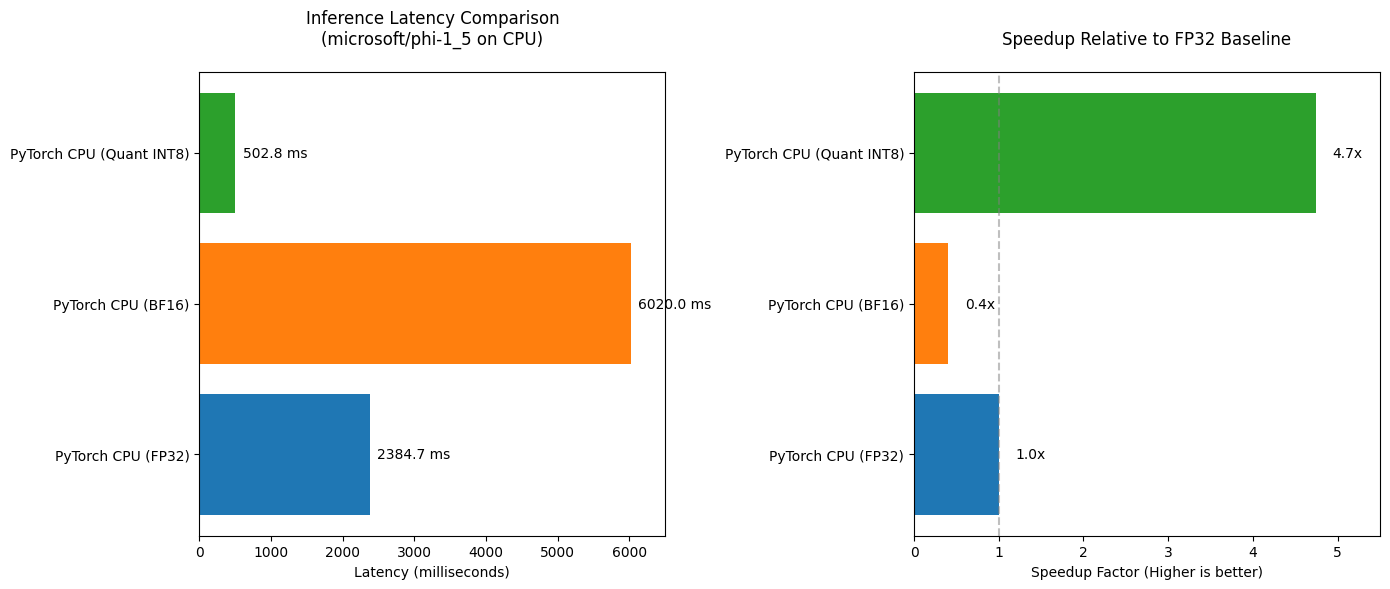

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Benchmark data
data = {
    "Method": [
        "PyTorch CPU (FP32)",
        "PyTorch CPU (BF16)",
        "PyTorch CPU (Quant INT8)"
    ],
    "Latency (ms)": [2384.68, 6019.96, 502.77],
    "Speedup": [1.0, 0.40, 4.74]
}

df = pd.DataFrame(data)

# Create figure with two subplots
plt.figure(figsize=(14, 6))

# Plot 1: Latency Comparison
plt.subplot(1, 2, 1)
bars = plt.barh(df['Method'], df['Latency (ms)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Inference Latency Comparison\n(microsoft/phi-1_5 on CPU)', pad=20)
plt.xlabel('Latency (milliseconds)')
plt.xlim(0, 6500)

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 100, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f} ms', 
             ha='left', va='center')

# Plot 2: Speedup Factor
plt.subplot(1, 2, 2)
speedup_bars = plt.barh(df['Method'], df['Speedup'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Speedup Relative to FP32 Baseline', pad=20)
plt.xlabel('Speedup Factor (Higher is better)')
plt.xlim(0, 5.5)

# Add value labels and reference line
for bar in speedup_bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}x', 
             ha='left', va='center')
plt.axvline(x=1, color='gray', linestyle='--', alpha=0.5)

# Adjust layout and save
plt.tight_layout()
plt.savefig('phi1_5_cpu_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()

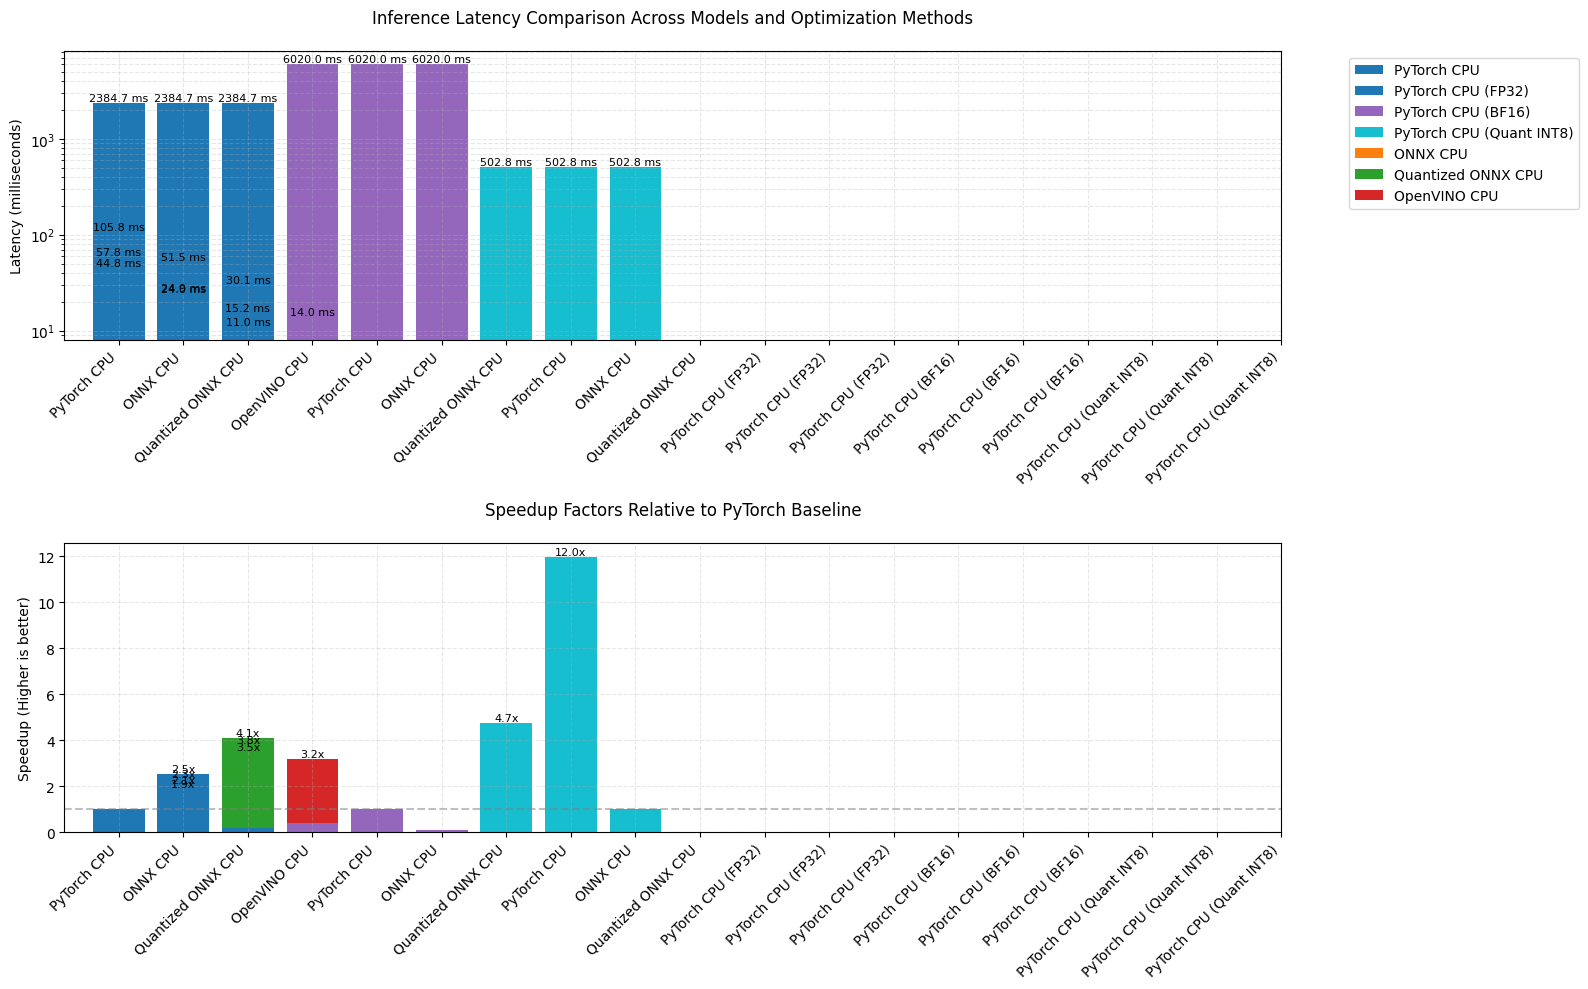

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Benchmark data
data = [
    {"Model": "distilbert-base-uncased", "Method": "PyTorch CPU", "Latency (ms)": 44.8},
    {"Model": "distilbert-base-uncased", "Method": "ONNX CPU", "Latency (ms)": 23.99},
    {"Model": "distilbert-base-uncased", "Method": "Quantized ONNX CPU", "Latency (ms)": 10.97},
    {"Model": "distilbert-base-uncased", "Method": "OpenVINO CPU", "Latency (ms)": 14.02},
    {"Model": "distilgpt2", "Method": "PyTorch CPU", "Latency (ms)": 57.82},
    {"Model": "distilgpt2", "Method": "ONNX CPU", "Latency (ms)": 24.9},
    {"Model": "distilgpt2", "Method": "Quantized ONNX CPU", "Latency (ms)": 15.16},
    {"Model": "EleutherAI/gpt-neo-125M", "Method": "PyTorch CPU", "Latency (ms)": 105.83},
    {"Model": "EleutherAI/gpt-neo-125M", "Method": "ONNX CPU", "Latency (ms)": 51.55},
    {"Model": "EleutherAI/gpt-neo-125M", "Method": "Quantized ONNX CPU", "Latency (ms)": 30.13},
    {"Model": "microsoft/phi-1_5", "Method": "PyTorch CPU (FP32)", "Latency (ms)": 2384.68},
    {"Model": "microsoft/phi-1_5", "Method": "PyTorch CPU (BF16)", "Latency (ms)": 6019.96},
    {"Model": "microsoft/phi-1_5", "Method": "PyTorch CPU (Quant INT8)", "Latency (ms)": 502.77}
]

df = pd.DataFrame(data)

# Calculate speedup factors
baselines = df[df['Method'].str.contains('PyTorch CPU(?! BF16)')]
df = df.merge(baselines[['Model', 'Latency (ms)']], on='Model', suffixes=('', '_baseline'))
df['Speedup'] = df['Latency (ms)_baseline'] / df['Latency (ms)']
df.drop('Latency (ms)_baseline', axis=1, inplace=True)

# Create visualization
plt.figure(figsize=(16, 10))

# Color mapping
method_colors = {
    'PyTorch CPU': '#1f77b4',
    'PyTorch CPU (FP32)': '#1f77b4',
    'PyTorch CPU (BF16)': '#9467bd',
    'PyTorch CPU (Quant INT8)': '#17becf',
    'ONNX CPU': '#ff7f0e',
    'Quantized ONNX CPU': '#2ca02c',
    'OpenVINO CPU': '#d62728'
}

# Plot 1: Latency Comparison by Model
plt.subplot(2, 1, 1)
for model in df['Model'].unique():
    model_data = df[df['Model'] == model]
    x = np.arange(len(model_data))
    bars = plt.bar(x, model_data['Latency (ms)'], 
                  color=[method_colors[m] for m in model_data['Method']],
                  label=model)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f} ms',
                ha='center', va='bottom', fontsize=8)

plt.title('Inference Latency Comparison Across Models and Optimization Methods', pad=20)
plt.ylabel('Latency (milliseconds)')
plt.xticks(np.arange(len(df)), df['Method'], rotation=45, ha='right')
plt.yscale('log')  # Log scale for better visualization of wide range
plt.grid(True, which="both", ls="--", alpha=0.3)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=method) 
                  for method, color in method_colors.items()]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Speedup Factors
plt.subplot(2, 1, 2)
for model in df['Model'].unique():
    model_data = df[df['Model'] == model]
    x = np.arange(len(model_data))
    bars = plt.bar(x, model_data['Speedup'],
                  color=[method_colors[m] for m in model_data['Method']])
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        if height > 1:  # Only label speedups
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}x',
                    ha='center', va='bottom', fontsize=8)

plt.title('Speedup Factors Relative to PyTorch Baseline', pad=20)
plt.ylabel('Speedup (Higher is better)')
plt.xticks(np.arange(len(df)), df['Method'], rotation=45, ha='right')
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)  # Baseline reference
plt.grid(True, which="both", ls="--", alpha=0.3)

plt.tight_layout()
plt.savefig('complete_benchmark_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

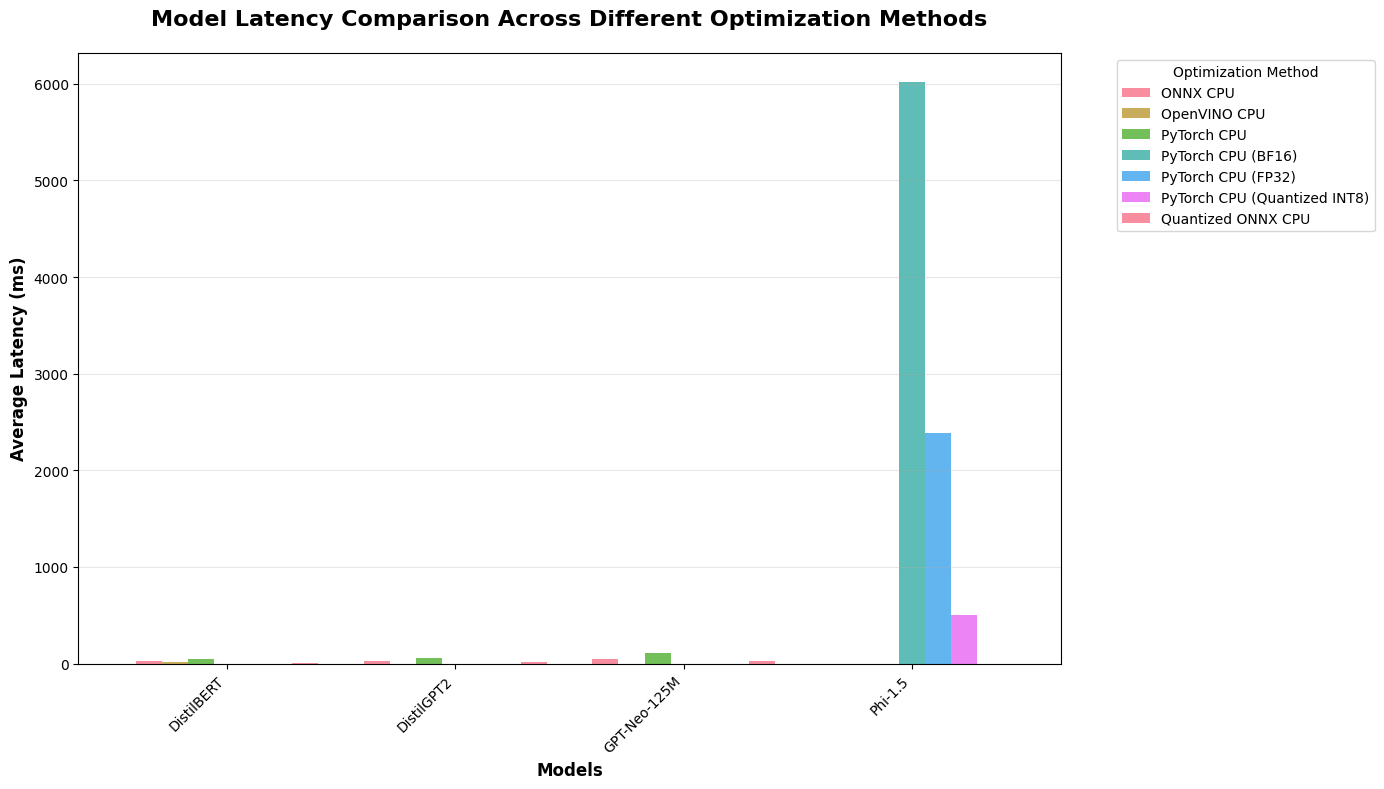

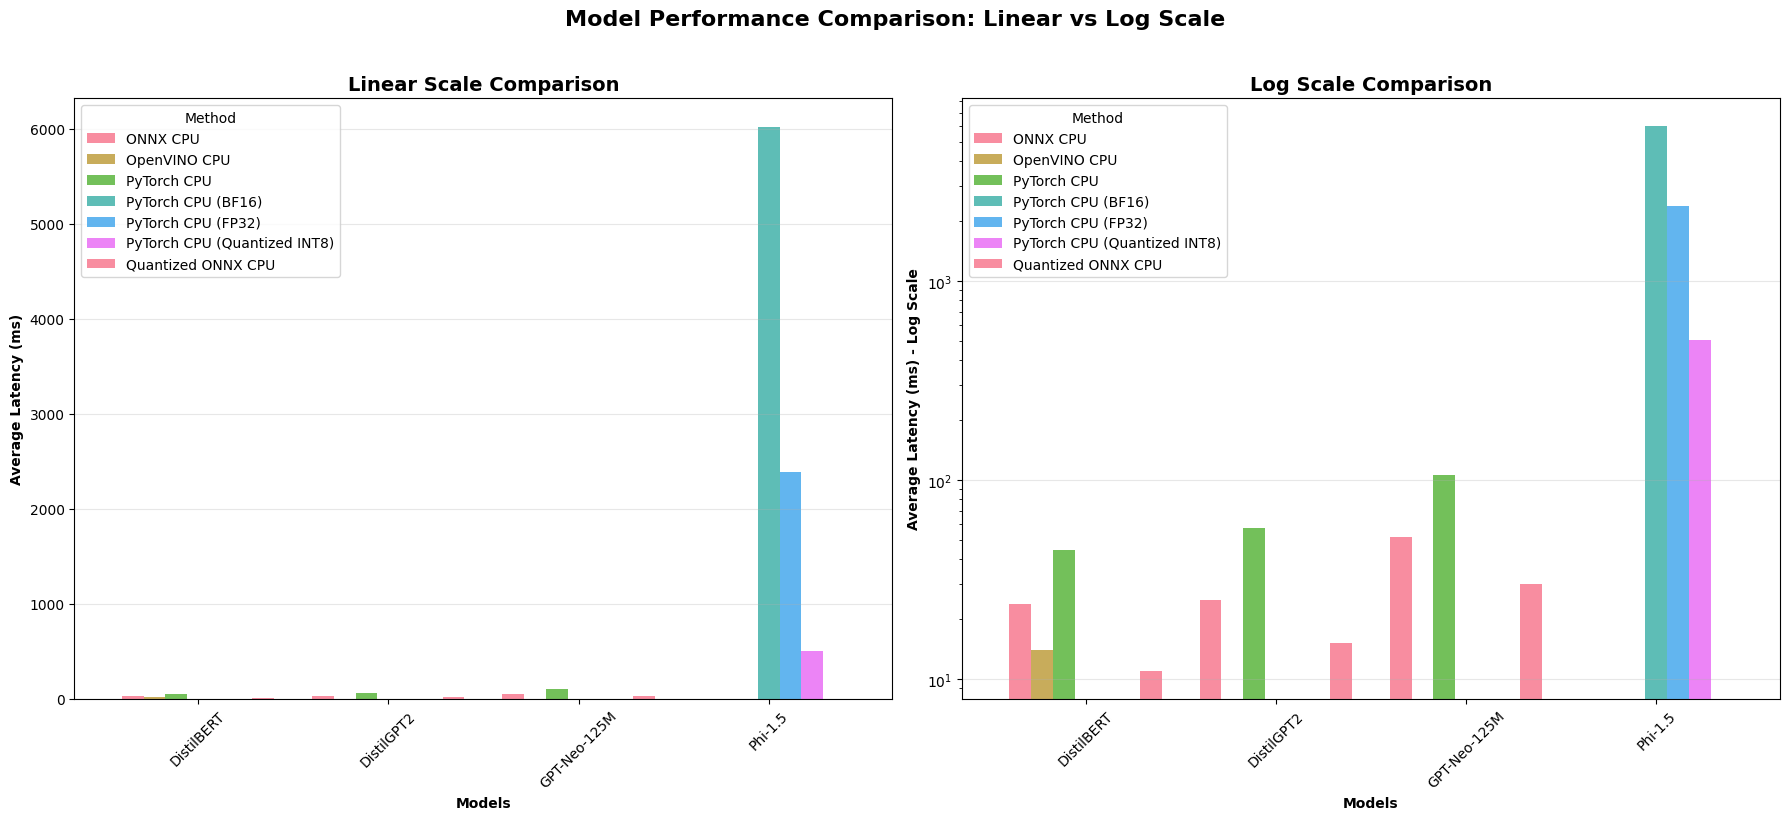

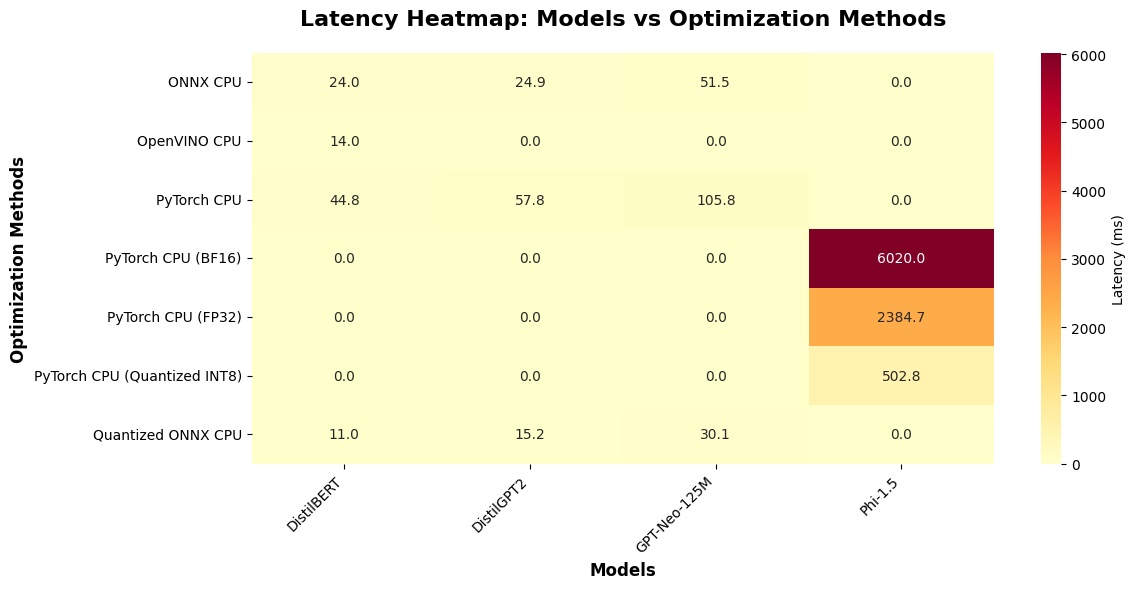

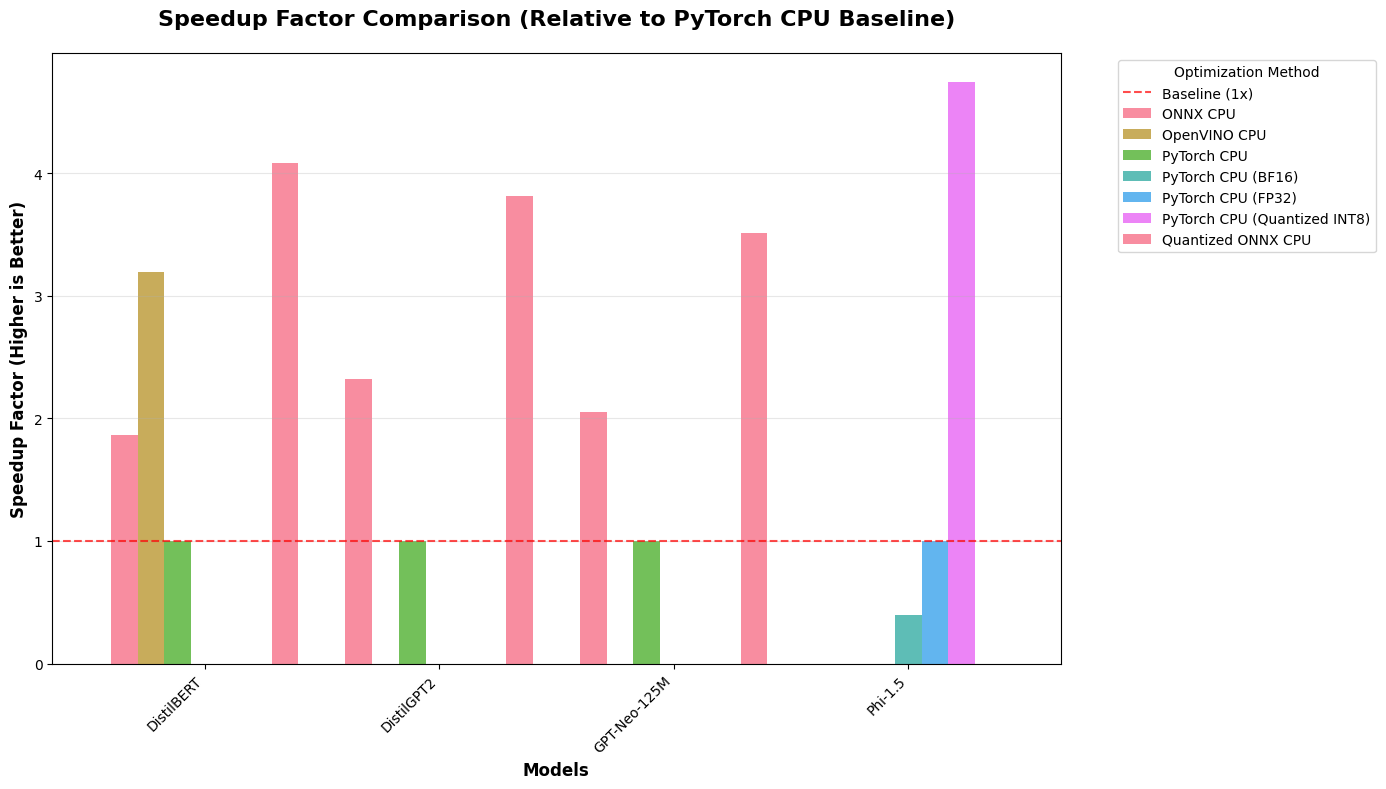

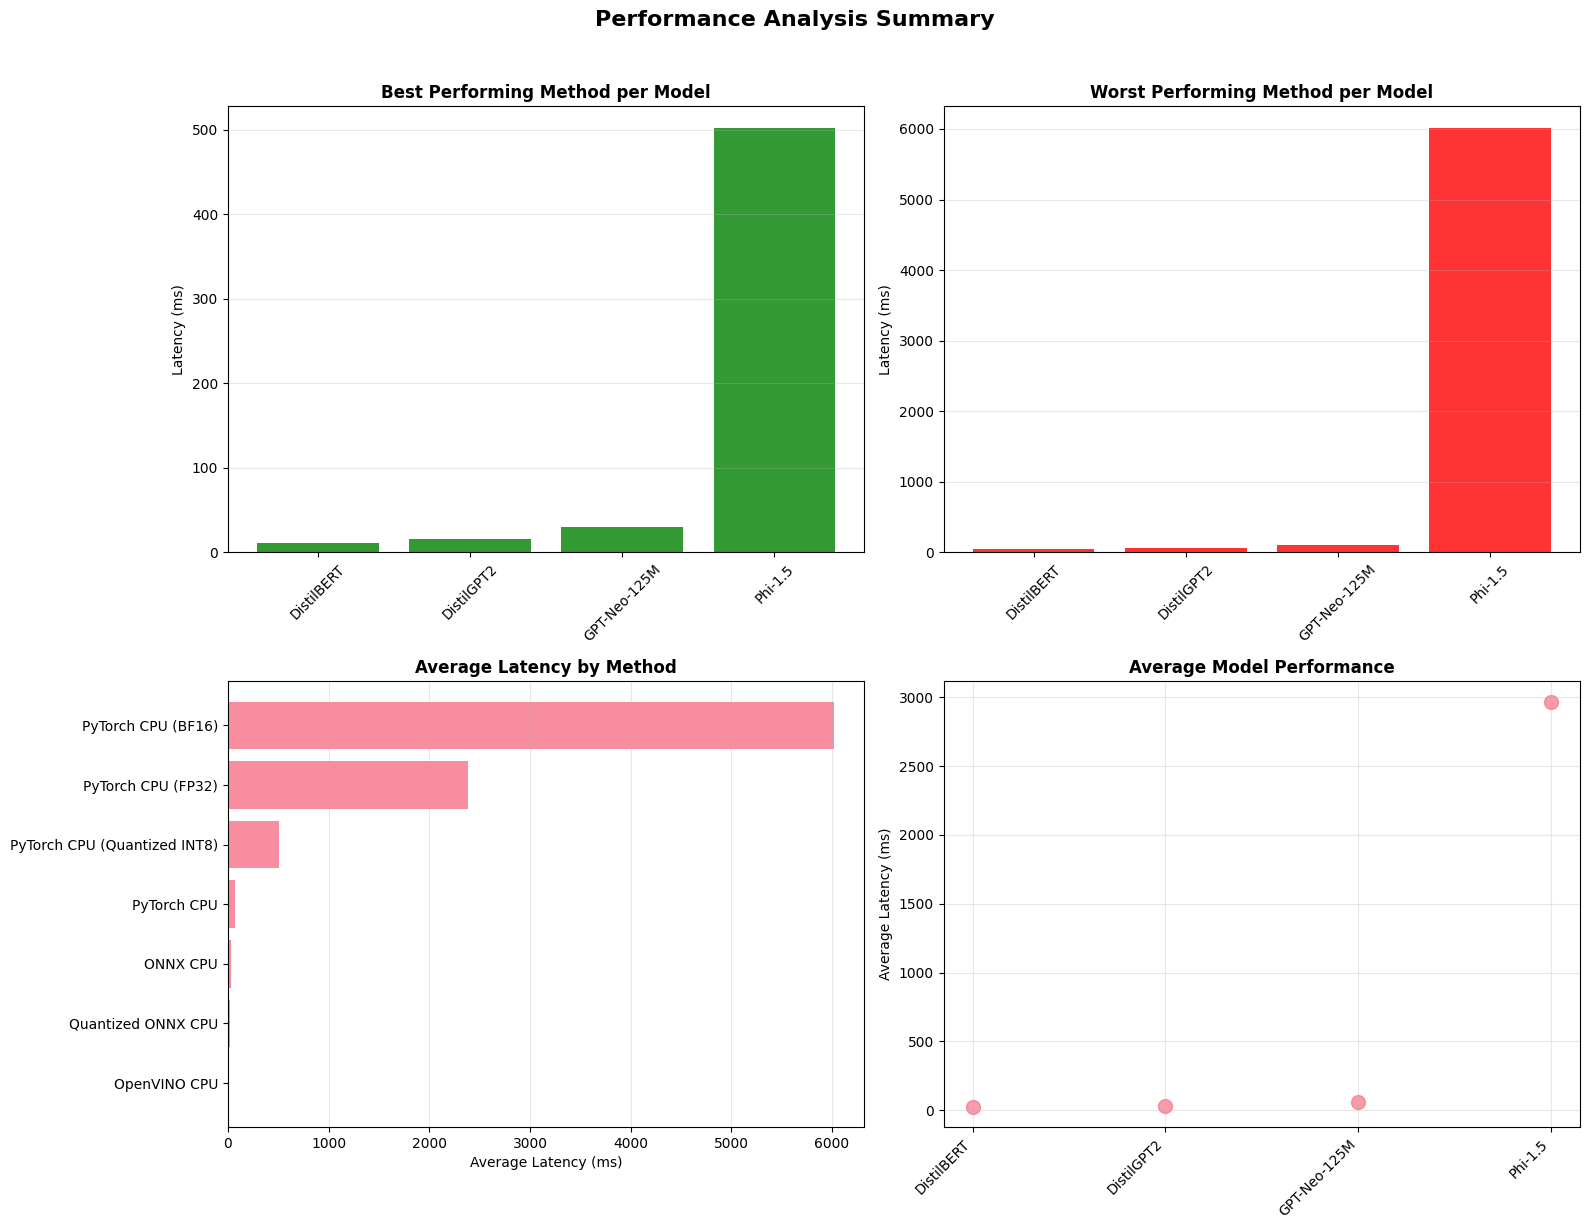

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Rectangle
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")

# Create the data
data = {
    'Model': [
        'distilbert-base-uncased', 'distilbert-base-uncased', 'distilbert-base-uncased', 'distilbert-base-uncased',
        'distilgpt2', 'distilgpt2', 'distilgpt2',
        'EleutherAI/gpt-neo-125M', 'EleutherAI/gpt-neo-125M', 'EleutherAI/gpt-neo-125M',
        'microsoft/phi-1_5', 'microsoft/phi-1_5', 'microsoft/phi-1_5'
    ],
    'Method': [
        'PyTorch CPU', 'ONNX CPU', 'Quantized ONNX CPU', 'OpenVINO CPU',
        'PyTorch CPU', 'ONNX CPU', 'Quantized ONNX CPU',
        'PyTorch CPU', 'ONNX CPU', 'Quantized ONNX CPU',
        'PyTorch CPU (FP32)', 'PyTorch CPU (BF16)', 'PyTorch CPU (Quantized INT8)'
    ],
    'Latency': [
        44.8, 23.99, 10.97, 14.02,
        57.82, 24.9, 15.16,
        105.83, 51.55, 30.13,
        2384.68, 6019.96, 502.77
    ]
}

df = pd.DataFrame(data)

# Create shorter model names for better visualization
df['Model_Short'] = df['Model'].str.replace('distilbert-base-uncased', 'DistilBERT')
df['Model_Short'] = df['Model_Short'].str.replace('distilgpt2', 'DistilGPT2')
df['Model_Short'] = df['Model_Short'].str.replace('EleutherAI/gpt-neo-125M', 'GPT-Neo-125M')
df['Model_Short'] = df['Model_Short'].str.replace('microsoft/phi-1_5', 'Phi-1.5')

# 1. Grouped Bar Chart - Main Comparison
fig, ax = plt.subplots(figsize=(14, 8))
pivot_df = df.pivot(index='Model_Short', columns='Method', values='Latency').fillna(0)
pivot_df.plot(kind='bar', ax=ax, width=0.8, alpha=0.8)

plt.title('Model Latency Comparison Across Different Optimization Methods', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Average Latency (ms)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Optimization Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Linear vs Log Scale Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

pivot_df.plot(kind='bar', ax=ax1, width=0.8, alpha=0.8)
ax1.set_title('Linear Scale Comparison', fontsize=14, fontweight='bold')
ax1.set_xlabel('Models', fontweight='bold')
ax1.set_ylabel('Average Latency (ms)', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

pivot_df.plot(kind='bar', ax=ax2, width=0.8, alpha=0.8, logy=True)
ax2.set_title('Log Scale Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Models', fontweight='bold')
ax2.set_ylabel('Average Latency (ms) - Log Scale', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison: Linear vs Log Scale', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. Heatmap Visualization
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_df.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            ax=ax, cbar_kws={'label': 'Latency (ms)'})
plt.title('Latency Heatmap: Models vs Optimization Methods', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Optimization Methods', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Speedup Factor Analysis
fig, ax = plt.subplots(figsize=(14, 8))

speedup_data = []
models = df['Model_Short'].unique()

for model in models:
    model_data = df[df['Model_Short'] == model]
    pytorch_baseline = None
    for _, row in model_data.iterrows():
        if 'PyTorch CPU' in row['Method'] and ('FP32' in row['Method'] or len(row['Method'].split()) == 2):
            pytorch_baseline = row['Latency']
            break
    
    if pytorch_baseline:
        for _, row in model_data.iterrows():
            speedup = pytorch_baseline / row['Latency']
            speedup_data.append({
                'Model': model,
                'Method': row['Method'],
                'Speedup': speedup
            })

speedup_df = pd.DataFrame(speedup_data)
speedup_pivot = speedup_df.pivot(index='Model', columns='Method', values='Speedup').fillna(0)
speedup_pivot.plot(kind='bar', ax=ax, width=0.8, alpha=0.8)

plt.title('Speedup Factor Comparison (Relative to PyTorch CPU Baseline)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Models', fontsize=12, fontweight='bold')
plt.ylabel('Speedup Factor (Higher is Better)', fontsize=12, fontweight='bold')
plt.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='Baseline (1x)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Optimization Method', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Performance Summary Statistics
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Best performing method per model
best_methods = df.loc[df.groupby('Model_Short')['Latency'].idxmin()]
ax1.bar(best_methods['Model_Short'], best_methods['Latency'], alpha=0.8, color='green')
ax1.set_title('Best Performing Method per Model', fontweight='bold')
ax1.set_ylabel('Latency (ms)')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Worst performing method per model
worst_methods = df.loc[df.groupby('Model_Short')['Latency'].idxmax()]
ax2.bar(worst_methods['Model_Short'], worst_methods['Latency'], alpha=0.8, color='red')
ax2.set_title('Worst Performing Method per Model', fontweight='bold')
ax2.set_ylabel('Latency (ms)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Method efficiency ranking
method_avg = df.groupby('Method')['Latency'].mean().sort_values()
ax3.barh(range(len(method_avg)), method_avg.values, alpha=0.8)
ax3.set_yticks(range(len(method_avg)))
ax3.set_yticklabels(method_avg.index)
ax3.set_title('Average Latency by Method', fontweight='bold')
ax3.set_xlabel('Average Latency (ms)')
ax3.grid(axis='x', alpha=0.3)

# Model performance scatter
model_avg = df.groupby('Model_Short')['Latency'].mean().sort_values()
ax4.scatter(range(len(model_avg)), model_avg.values, s=100, alpha=0.7)
ax4.set_xticks(range(len(model_avg)))
ax4.set_xticklabels(model_avg.index, rotation=45, ha='right')
ax4.set_title('Average Model Performance', fontweight='bold')
ax4.set_ylabel('Average Latency (ms)')
ax4.grid(alpha=0.3)

plt.suptitle('Performance Analysis Summary', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


--- Final Project Performance Summary ---
       Model             Method  Latency (ms)
  DistilBERT        PyTorch CPU         44.80
  DistilBERT           ONNX CPU         23.99
  DistilBERT     Quantized ONNX         10.97
  DistilBERT           OpenVINO         14.02
 DistilGPT-2        PyTorch CPU         57.82
 DistilGPT-2           ONNX CPU         24.90
 DistilGPT-2     Quantized ONNX         15.16
GPT-Neo 125M        PyTorch CPU        105.83
GPT-Neo 125M           ONNX CPU         51.55
GPT-Neo 125M     Quantized ONNX         30.13
Phi-1.5 1.5B PyTorch CPU (FP32)       2384.68
Phi-1.5 1.5B PyTorch CPU (BF16)       6019.96
Phi-1.5 1.5B PyTorch CPU (INT8)        502.77


--- Generating final performance chart ---
✅ Final chart saved to final_project_comparison.png


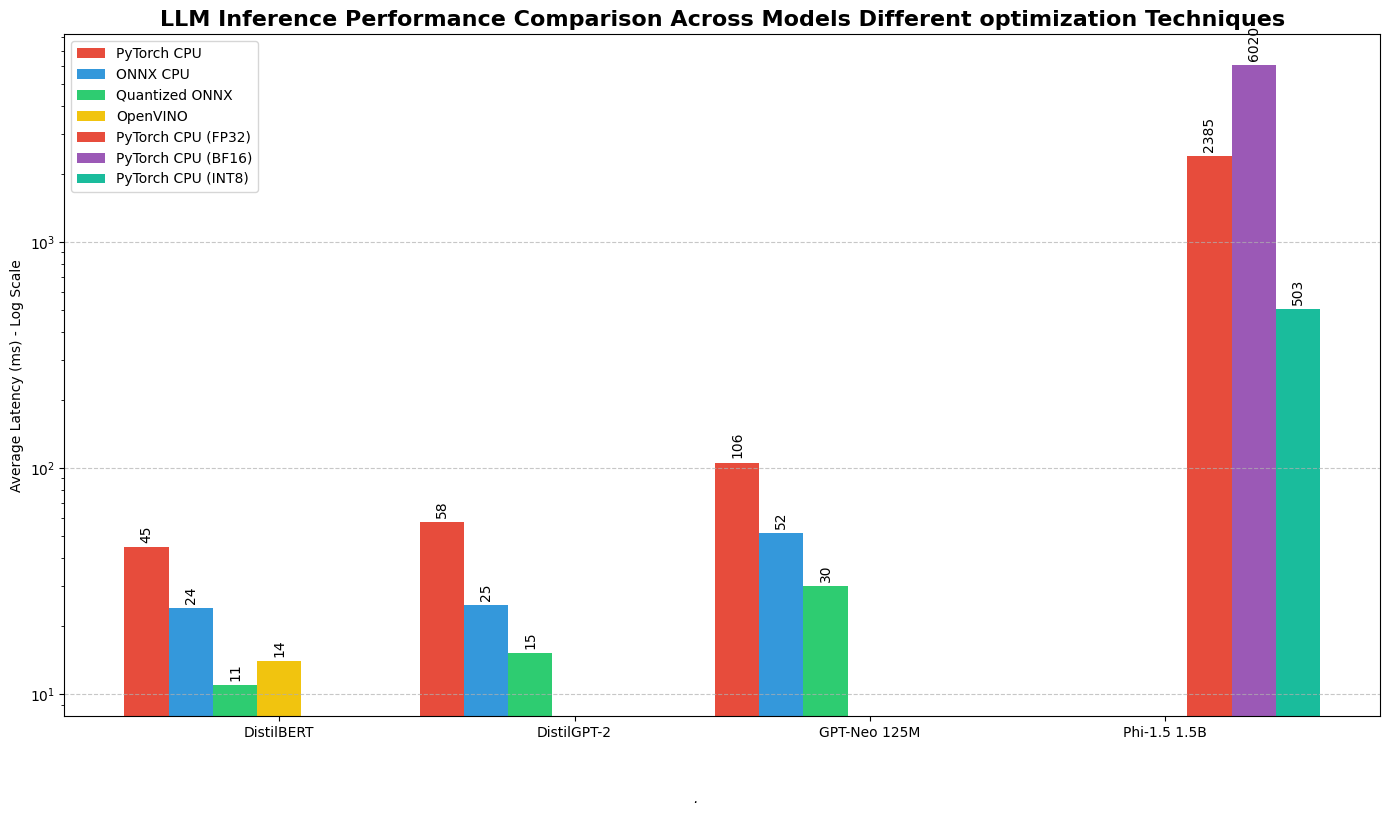

In [13]:
# File: Final_Project_Report.py
# Purpose: Consolidate all benchmark results from the project and create a
#          final summary plot comparing all models and optimization techniques.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- ACTION REQUIRED: All of your final results are entered here ---
all_benchmark_data = [
    # Model 1: distilbert-base-uncased
    {"Model": "DistilBERT", "Method": "PyTorch CPU", "Latency (ms)": 44.8},
    {"Model": "DistilBERT", "Method": "ONNX CPU", "Latency (ms)": 23.99},
    {"Model": "DistilBERT", "Method": "Quantized ONNX", "Latency (ms)": 10.97},
    {"Model": "DistilBERT", "Method": "OpenVINO", "Latency (ms)": 14.02},
    
    # Model 2: distilgpt2
    {"Model": "DistilGPT-2", "Method": "PyTorch CPU", "Latency (ms)": 57.82},
    {"Model": "DistilGPT-2", "Method": "ONNX CPU", "Latency (ms)": 24.9},
    {"Model": "DistilGPT-2", "Method": "Quantized ONNX", "Latency (ms)": 15.16},

    # Model 3: EleutherAI/gpt-neo-125M
    {"Model": "GPT-Neo 125M", "Method": "PyTorch CPU", "Latency (ms)": 105.83},
    {"Model": "GPT-Neo 125M", "Method": "ONNX CPU", "Latency (ms)": 51.55},
    {"Model": "GPT-Neo 125M", "Method": "Quantized ONNX", "Latency (ms)": 30.13},

    # Model 4: microsoft/phi-1_5
    {"Model": "Phi-1.5 1.5B", "Method": "PyTorch CPU (FP32)", "Latency (ms)": 2384.68},
    {"Model": "Phi-1.5 1.5B", "Method": "PyTorch CPU (BF16)", "Latency (ms)": 6019.96},
    {"Model": "Phi-1.5 1.5B", "Method": "PyTorch CPU (INT8)", "Latency (ms)": 502.77},
]

# --- Create and process the DataFrame ---
df = pd.DataFrame(all_benchmark_data)

# --- Display the Final Summary Table ---
print("="*60)
print("--- Final Project Performance Summary ---")
print("="*60)
print(df.to_string(index=False))
print("\n")

# --- Generate and Save the Final Plot ---
print("--- Generating final performance chart ---")

# Use a log scale for the y-axis to better visualize the large differences in latency
fig, ax = plt.subplots(figsize=(14, 8))

# Group data by model and method for plotting
models = df['Model'].unique()
methods = df['Method'].unique()
x = np.arange(len(models))  # the label locations
width = 0.15  # the width of the bars
multiplier = 0

# Define a color map for methods
color_map = {
    'PyTorch CPU': '#e74c3c',
    'ONNX CPU': '#3498db',
    'Quantized ONNX': '#2ecc71',
    'OpenVINO': '#f1c40f',
    'PyTorch CPU (FP32)': '#e74c3c',
    'PyTorch CPU (BF16)': '#9b59b6',
    'PyTorch CPU (INT8)': '#1abc9c'
}


for method in methods:
    method_data = df[df['Method'] == method]
    # Align data to the models on the x-axis
    latencies = []
    for model_name in models:
        if model_name in method_data['Model'].values:
            latencies.append(method_data[method_data['Model'] == model_name]['Latency (ms)'].iloc[0])
        else:
            latencies.append(0) # Add a zero for models that don't have this method
            
    offset = width * multiplier
    rects = ax.bar(x + offset, latencies, width, label=method, color=color_map.get(method, '#bdc3c7'))
    ax.bar_label(rects, padding=3, rotation=90, fmt='%.0f')
    multiplier += 1

# --- Add Titles and Labels ---
ax.set_ylabel('Average Latency (ms) - Log Scale')
ax.set_title('LLM Inference Performance Comparison Across Models Different optimization Techniques', fontsize=16, fontweight='bold')
ax.set_xticks(x + width * (len(methods) / 2 - 0.5))
ax.set_xticklabels(models)
ax.legend(loc='upper left', ncols=1)
ax.set_yscale('log') # Use a logarithmic scale to handle the large range of values
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add a caption
caption = (
    "."
)
fig.text(0.5, -0.01, caption, ha='center', fontsize=10, style='italic', wrap=True)


plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("final_project_comparison.png", bbox_inches='tight')
print("✅ Final chart saved to final_project_comparison.png")
plt.show()



In [19]:
# File: Energy_Benchmark_distilgpt2.py
# Purpose: Measure the energy consumption of the optimized quantized 'distilgpt2' LLM.

import os
import time
import onnxruntime
import numpy as np
import pandas as pd
from transformers import AutoTokenizer
from codecarbon import OfflineEmissionsTracker

# --- Configuration ---
MODEL_ID = "distilgpt2"
PROMPT = "The future of AI is"
NUM_RUNS = 200
ONNX_QUANTIZED_PATH = f"{MODEL_ID.replace('/', '_')}_causal_quantized.onnx"

def run_energy_benchmark(session, inputs):
    """Tracks and reports latency and energy consumption."""
    print(f"\n--- Benchmarking Latency and Energy for: {MODEL_ID} ---")
    
    # --- Latency Measurement ---
    session.run(None, inputs) # Warm-up
    latencies = []
    print(f"Running latency benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        outputs = session.run(None, inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    avg_latency = np.mean(latencies)
    
    # --- Energy Measurement ---
    tracker = OfflineEmissionsTracker(country_iso_code="ITA", log_level='ERROR')
    
    print(f"Running energy benchmark ({NUM_RUNS} runs)...")
    tracker.start()
    for _ in range(NUM_RUNS):
        session.run(None, inputs)
    total_energy_kwh = tracker.stop()
    
    total_energy_joules = total_energy_kwh * 3.6e6
    avg_energy_per_inference = total_energy_joules / NUM_RUNS

    result = {
        "Model": MODEL_ID,
        "Avg Latency (ms)": round(avg_latency, 2),
        "Avg Energy per Inference (Joules)": round(avg_energy_per_inference, 4)
    }
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*60)
    print(f"HPC Energy Benchmark for: {MODEL_ID}")
    print("="*60)

    if not os.path.exists(ONNX_QUANTIZED_PATH):
        raise FileNotFoundError(f"Quantized model not found at '{ONNX_QUANTIZED_PATH}'.")

    session = onnxruntime.InferenceSession(ONNX_QUANTIZED_PATH, providers=['CPUExecutionProvider'])
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_inputs = tokenizer(PROMPT, return_tensors="pt")
    onnx_inputs = {k: v.cpu().numpy() for k, v in pt_inputs.items()}

    benchmark_result = run_energy_benchmark(session, onnx_inputs)
    
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))



HPC Energy Benchmark for: distilgpt2

--- Benchmarking Latency and Energy for: distilgpt2 ---
Running latency benchmark (200 runs)...


[codecarbon INFO @ 03:07:20] offline tracker init
[codecarbon WARNING @ 03:07:20] Multiple instances of codecarbon are allowed to run at the same time.


Running energy benchmark (200 runs)...

--- Benchmark Result ---
     Model  Avg Latency (ms)  Avg Energy per Inference (Joules)
distilgpt2              9.81                             0.1214


In [20]:
# File: Energy_Benchmark_gpt-neo-125M.py
# Purpose: Measure the energy consumption of the optimized quantized 'gpt-neo-125M' LLM.

import os
import time
import onnxruntime
import numpy as np
import pandas as pd
from transformers import AutoTokenizer
from codecarbon import OfflineEmissionsTracker

# --- Configuration ---
MODEL_ID = "EleutherAI/gpt-neo-125M"
PROMPT = "In a world where artificial intelligence is rapidly advancing,"
NUM_RUNS = 200
ONNX_QUANTIZED_PATH = f"{MODEL_ID.replace('/', '_')}_causal_quantized.onnx"

def run_energy_benchmark(session, inputs):
    """Tracks and reports latency and energy consumption."""
    print(f"\n--- Benchmarking Latency and Energy for: {MODEL_ID} ---")
    
    # --- Latency Measurement ---
    session.run(None, inputs) # Warm-up
    latencies = []
    print(f"Running latency benchmark ({NUM_RUNS} runs)...")
    for _ in range(NUM_RUNS):
        start_time = time.perf_counter()
        outputs = session.run(None, inputs)
        end_time = time.perf_counter()
        latencies.append((end_time - start_time) * 1000)
    avg_latency = np.mean(latencies)
    
    # --- Energy Measurement ---
    tracker = OfflineEmissionsTracker(country_iso_code="ITA", log_level='ERROR')
    
    print(f"Running energy benchmark ({NUM_RUNS} runs)...")
    tracker.start()
    for _ in range(NUM_RUNS):
        session.run(None, inputs)
    total_energy_kwh = tracker.stop()
    
    total_energy_joules = total_energy_kwh * 3.6e6
    avg_energy_per_inference = total_energy_joules / NUM_RUNS

    result = {
        "Model": MODEL_ID,
        "Avg Latency (ms)": round(avg_latency, 2),
        "Avg Energy per Inference (Joules)": round(avg_energy_per_inference, 4)
    }
    return result

# --- Main Execution Block ---
if __name__ == "__main__":
    print("="*60)
    print(f"HPC Energy Benchmark for: {MODEL_ID}")
    print("="*60)

    if not os.path.exists(ONNX_QUANTIZED_PATH):
        raise FileNotFoundError(f"Quantized model not found at '{ONNX_QUANTIZED_PATH}'.")

    session = onnxruntime.InferenceSession(ONNX_QUANTIZED_PATH, providers=['CPUExecutionProvider'])
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    pt_inputs = tokenizer(PROMPT, return_tensors="pt")
    onnx_inputs = {k: v.cpu().numpy() for k, v in pt_inputs.items()}

    benchmark_result = run_energy_benchmark(session, onnx_inputs)
    
    df = pd.DataFrame([benchmark_result])
    print("\n--- Benchmark Result ---")
    print(df.to_string(index=False))



HPC Energy Benchmark for: EleutherAI/gpt-neo-125M

--- Benchmarking Latency and Energy for: EleutherAI/gpt-neo-125M ---
Running latency benchmark (200 runs)...
Running energy benchmark (200 runs)...

--- Benchmark Result ---
                  Model  Avg Latency (ms)  Avg Energy per Inference (Joules)
EleutherAI/gpt-neo-125M             26.09                             0.3436
